# Closed-Loop Voltage Control with Latent-Space RL

Koopman-with-control models learn an input matrix **B** so latent dynamics follow
$z_{t+1} = K z_t + B u_t$. That enables open-loop planning, but many power-system
applications need **closed-loop** policies that react to the current state.

This notebook wraps a trained `GraphKoopmanModel` as a **Gymnasium** environment
where:

- **Observations** are flattened latent node states $z_t$ (encoder frozen).
- **Actions** are global control inputs $u_t$ (load-ramp setpoints).
- **Rewards** are computed on **decoded physical voltages** $V_m$.

We demonstrate manual environment interaction, then optional PPO training via
Stable-Baselines3 (`pip install koopman-graph[rl]`).

> **Scope.** The IEEE 118 benchmark uses simplified voltage diffusion plus a
> synthetic load ramp — a stand-in for voltage regulation, not a full AC power
> flow solver. The encoder/decoder remain frozen during RL; only the control
> input changes latent transitions.

## Workflow

1. **Offline fit** — train a controlled $V_m$ Koopman model on IEEE 118 with the
   load ramp exposed as a global control input.
2. **Latent env** — wrap the model with `to_latent_env` and a voltage MSE reward
   on decoded states.
3. **Baselines** — roll out nominal open-loop and heuristic feedback policies
   from a fixed start snapshot.
4. **PPO (optional)** — train Stable-Baselines3 on the latent env when the
   `[rl]` extra is installed.
5. **Compare** — plot decoded trajectories and cumulative returns.

In [1]:
import os
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings('ignore', category=TqdmWarning)

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get('PYTEST_CURRENT_TEST'):
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get('PYTEST_CURRENT_TEST'):
        get_ipython().run_line_magic('matplotlib', 'inline')
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets import IEEE118DynamicBenchmark

try:
    from stable_baselines3 import PPO

    SB3_AVAILABLE = True
except ImportError:
    SB3_AVAILABLE = False

IS_CI = bool(os.environ.get('PYTEST_CURRENT_TEST'))
torch.manual_seed(0)
np.random.seed(0)

## Offline fit: controlled Vm model

We train on **voltage magnitude (Vm) only** with the benchmark load ramp exposed
as a global control input (`control_dim=1`), matching the controlled-dynamics
section in `02_ieee118_bus.ipynb`.

In [2]:
NUM_TIMESTEPS = 20 if IS_CI else 32
EPOCHS = 25 if IS_CI else 80
HIDDEN = 32
LATENT = 16
TARGET_VM = 1.0

controlled_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=NUM_TIMESTEPS,
    expose_load_ramp_control=True,
    seed=7,
)

vm_sequence = GraphSnapshotSequence(
    [Data(x=s.x[:, :1], edge_index=s.edge_index) for s in controlled_sequence],
    control_inputs=controlled_sequence.control_inputs,
)

encoder = GNNEncoder(1, HIDDEN, LATENT)
decoder = GNNDecoder(LATENT, HIDDEN, 1)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT,
    time_step=0.25,
    control_dim=1,
    koopman_parameterization='lyapunov',
)

history = model.fit(vm_sequence, epochs=EPOCHS, lr=1e-3, max_grad_norm=1.0)
print(f"Snapshots: {vm_sequence.num_timesteps}, final loss: {history.loss[-1]:.4f}")

Snapshots: 32, final loss: 0.0091


## Build the latent Gymnasium environment

The reward penalizes mean squared deviation of decoded $V_m$ from 1.0 p.u.
Actions are clipped to `[-1, 1]` by default (the benchmark generator uses load
ramp multipliers near 1.0 during training).

In [3]:
def voltage_reward(snapshot: Data, step_index: int) -> float:
    vm = snapshot.x[:, 0]
    return float(-torch.mean((vm - TARGET_VM) ** 2).item())


MAX_STEPS = 8 if IS_CI else 16
START = vm_sequence.num_timesteps // 3

env = model.to_latent_env(
    vm_sequence,
    voltage_reward,
    max_episode_steps=MAX_STEPS,
    random_start=False,
    start_index=START,
)

print(f"Observation dim: {env.observation_space.shape[0]}")
print(f"Action dim: {env.action_space.shape[0]}")

Observation dim: 1888
Action dim: 1


## Manual rollout (no RL library required)

The benchmark exposes the sinusoidal **load-ramp multiplier** as the control
input. We compare two hand-designed policies from the same reset state; PPO is
evaluated in the next section.

1. **Nominal ramp** — hold $u_t = 1.0$, the neutral multiplier seen during
   offline training (open-loop baseline).
2. **Heuristic feedback** — set $u_t$ proportional to the negative mean voltage
   error (clipped inside the env).

In [4]:
def rollout_policy(env, policy_fn, seed: int = 0):
    obs, info = env.reset(seed=seed)
    voltages = [info['decoded_x'][:, 0].copy()]
    rewards = []
    truncated = False
    step_idx = 0
    while not truncated:
        action = policy_fn(info['decoded_x'][:, 0], step_idx)
        obs, reward, terminated, truncated, info = env.step(action)
        voltages.append(info['decoded_x'][:, 0].copy())
        rewards.append(reward)
        step_idx += 1
    return np.asarray(voltages), np.asarray(rewards)


def nominal_policy(_vm, _step):
    # Neutral load-ramp multiplier used by the benchmark generator.
    return np.array([1.0], dtype=np.float32)


def heuristic_policy(vm, _step):
    # Push control opposite to mean voltage error (clipped inside env).
    error = float(np.mean(vm) - TARGET_VM)
    return np.array([-0.8 * error], dtype=np.float32)


nominal_vm, nominal_rewards = rollout_policy(env, nominal_policy)
heur_vm, heur_rewards = rollout_policy(env, heuristic_policy)

print(f"Nominal-ramp return: {nominal_rewards.sum():.4f}")
print(f"Heuristic return: {heur_rewards.sum():.4f}")

Nominal-ramp return: -1.7819
Heuristic return: -1.5984


## PPO in latent space (optional `[rl]` extra)

When Stable-Baselines3 is installed, we train PPO for 12k timesteps on CPU
(4k under nbmake/CI). Training uses random episode starts; evaluation reuses
the fixed `start_index` from the baseline rollouts.

In [5]:
ppo_vm = None
ppo_rewards = None

if SB3_AVAILABLE:
    train_env = model.to_latent_env(
        vm_sequence,
        voltage_reward,
        max_episode_steps=MAX_STEPS,
        random_start=True,
    )
    total_timesteps = 4_000 if IS_CI else 12_000
    ppo = PPO(
        'MlpPolicy',
        train_env,
        verbose=0,
        n_steps=256,
        batch_size=64,
        learning_rate=3e-4,
        seed=0,
    )
    ppo.learn(total_timesteps=total_timesteps)

    eval_env = model.to_latent_env(
        vm_sequence,
        voltage_reward,
        max_episode_steps=MAX_STEPS,
        random_start=False,
        start_index=START,
    )
    obs, info = eval_env.reset(seed=0)
    ppo_vm = [info['decoded_x'][:, 0].copy()]
    ppo_rewards = []
    truncated = False
    while not truncated:
        action, _ = ppo.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        ppo_vm.append(info['decoded_x'][:, 0].copy())
        ppo_rewards.append(reward)
    ppo_vm = np.asarray(ppo_vm)
    ppo_rewards = np.asarray(ppo_rewards)
    print(f"PPO return: {ppo_rewards.sum():.4f}")
else:
    print('stable-baselines3 not installed; skipping PPO demo.')
    print('Install with: pip install "koopman-graph[rl]"')

PPO return: -0.7252


## Compare policies

Plot network-mean decoded $V_m$ (solid) with faint per-bus traces for heuristic
and PPO, plus cumulative episode returns. All rollouts use the same fixed start
snapshot (`start_index = num_timesteps // 3`).

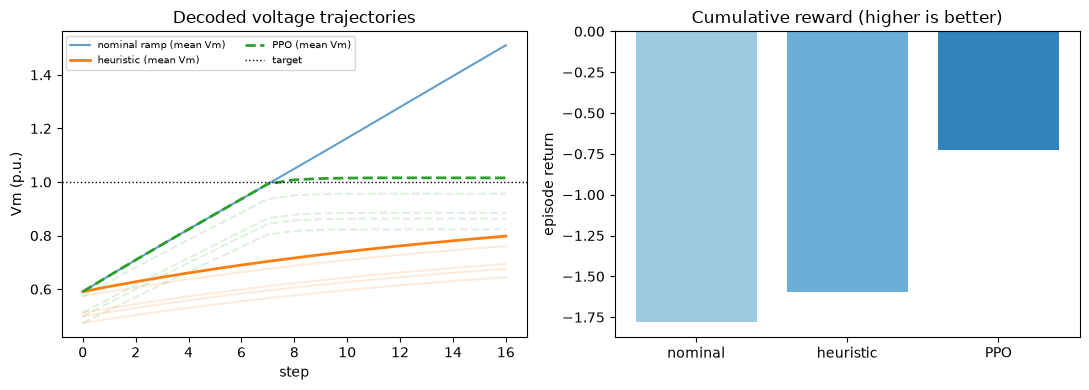

In [6]:
bus_idx = [0, 40, 80, 117]
steps = np.arange(nominal_vm.shape[0])
mean_nominal = nominal_vm.mean(axis=1)
mean_heur = heur_vm.mean(axis=1)
mean_ppo = ppo_vm.mean(axis=1) if ppo_vm is not None else None

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(steps, mean_nominal, alpha=0.7, label='nominal ramp (mean Vm)')
axes[0].plot(steps, mean_heur, linewidth=2, label='heuristic (mean Vm)')
if mean_ppo is not None:
    axes[0].plot(steps, mean_ppo, linestyle='--', linewidth=2, label='PPO (mean Vm)')
for idx in bus_idx:
    axes[0].plot(steps, heur_vm[:, idx], alpha=0.15, color='C1')
    if ppo_vm is not None:
        axes[0].plot(steps, ppo_vm[:, idx], alpha=0.15, color='C2', linestyle='--')
axes[0].axhline(TARGET_VM, color='k', linestyle=':', linewidth=1, label='target')
axes[0].set_xlabel('step')
axes[0].set_ylabel('Vm (p.u.)')
axes[0].set_title('Decoded voltage trajectories')
axes[0].legend(fontsize=7, ncol=2)

labels = ['nominal', 'heuristic']
returns = [nominal_rewards.sum(), heur_rewards.sum()]
if ppo_rewards is not None:
    labels.append('PPO')
    returns.append(ppo_rewards.sum())
axes[1].bar(labels, returns, color=['#9ecae1', '#6baed6', '#3182bd'][: len(labels)])
axes[1].set_ylabel('episode return')
axes[1].set_title('Cumulative reward (higher is better)')

plt.tight_layout()
plt.show()

## Takeaways

**Results.** With the default hyperparameters, episode returns improve
monotonically: nominal ramp < heuristic < PPO. PPO brings mean decoded voltage
closest to 1.0 p.u. (end ≈ 1.02). The nominal open-loop baseline can overshoot
(end ≈ 1.51) because it does not close the loop on voltage error — higher $V_m$
is not automatically better under the MSE reward.

**Scope.** These are closed-loop latent rollouts, not comparisons to the IEEE
118 simulator's ground-truth trajectory. The notebook demonstrates the
Gymnasium wrapper and control API, not grid-scale optimality.

**Limitations.**

- **Frozen encoder/decoder:** RL only adjusts the applied control $u_t$; it does
  not correct representation error from the offline GNN lift.
- **Global control:** one scalar load-ramp input drives all buses; realistic
  voltage control often uses regional setpoints.
- **Linear latent dynamics:** PPO optimizes over $z_{t+1} = K z_t + B u_t$;
  large disturbances may require online adaptation (`adapt_step`) or refitting.
- **Benchmark physics:** diffusion + ramp is a teaching surrogate, not a
  power-flow-accurate grid model.